In [ ]:
import cdsapi
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [4]:
ds = xr.load_dataset('../download.grib', engine ='cfgrib')

Ignoring index file '../download.grib.5b7b6.idx' incompatible with GRIB file


In [ ]:
print(ds)

<xarray.Dataset> Size: 7GB
Dimensions:     (time: 8760, latitude: 73, longitude: 1440)
Coordinates:
    number      int64 8B 0
  * time        (time) datetime64[ns] 70kB 2019-01-01 ... 2019-12-31T23:00:00
    step        timedelta64[ns] 8B 00:00:00
    surface     float64 8B 0.0
  * latitude    (latitude) float64 584B -62.0 -62.25 -62.5 ... -79.75 -80.0
  * longitude   (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    valid_time  (time) datetime64[ns] 70kB 2019-01-01 ... 2019-12-31T23:00:00
Data variables:
    u10         (time, latitude, longitude) float32 4GB 1.801 2.028 ... 3.911
    v10         (time, latitude, longitude) float32 4GB -4.191 -3.934 ... 3.164
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    histor

In [7]:
# Resample to daily means
ds_daily = ds.resample(time='1D').mean()

del(ds)

In [8]:
print(ds_daily)

<xarray.Dataset> Size: 307MB
Dimensions:    (latitude: 73, longitude: 1440, time: 365)
Coordinates:
    number     int64 8B 0
    step       timedelta64[ns] 8B 00:00:00
    surface    float64 8B 0.0
  * latitude   (latitude) float64 584B -62.0 -62.25 -62.5 ... -79.5 -79.75 -80.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * time       (time) datetime64[ns] 3kB 2019-01-01 2019-01-02 ... 2019-12-31
Data variables:
    u10        (time, latitude, longitude) float32 153MB -2.495 ... 0.6236
    v10        (time, latitude, longitude) float32 153MB -7.212 ... -3.471
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-12T11:25 GRIB to CDM+CF via cfgrib-0.9.1...


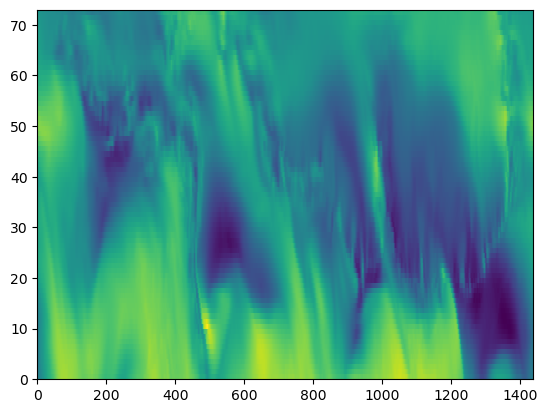

In [10]:
plt.pcolormesh(ds_daily.u10[0])

In [ ]:
np.savez(
    '../download.npz',
    ua = ds_daily.u10, 
    va = ds_daily.v10,
    time = ds_daily.time,
    lat = ds_daily.latitude,
    lon = ds_daily.longitude,
)